# Flight Delay Prediction with Linear Regression

**Problem:** Dự đoán `ArrDelay` (delay khi đến) cho các chuyến bay từ dataset `data/processed_flight_data.csv`.

Notebook này xây dựng một workflow Truyền thống cho Linear Regression với các bước: EDA, feature engineering, splitting, scaling, training, đánh giá, phân tích residual, baseline so sánh và lưu artifacts.

## Problem Statement

- Mục tiêu: tạo một baseline model dễ hiểu để dự đoán độ trễ khi đến (`ArrDelay`).
- Mô hình chính: `LinearRegression`.
- Yêu cầu: sử dụng `pandas`, `matplotlib`, `scikit-learn`.

In [13]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

data_path = Path('..') / 'data' / 'processed_flight_data.csv'
image_path = Path('..') / 'images'
model_path = Path('..') / 'models'

image_path.mkdir(parents=True, exist_ok=True)
model_path.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)
print('Loaded dataset with shape:', df.shape)
print('Selected target:', 'ArrDelay')

Loaded dataset with shape: (1868454, 45)
Selected target: ArrDelay


## Data Loading

- Kiểm tra dữ liệu thô.
- Kiểm tra các cột, shape và dữ liệu thiếu.  
- Đây là bước quan trọng để xác định feature phù hợp.

In [14]:
print(df.head(5).to_string(index=False))
print('\nColumn count:', len(df.columns))
print('Missing values per column:')
print(df.isna().sum().sort_values(ascending=False).head(10))

 Unnamed: 0  Month  DayofMonth  DayOfWeek  DepTime  ArrTime  CRSElapsedTime  ArrDelay  DepDelay Origin Dest  Distance  TaxiIn  TaxiOut CancellationCode  CarrierDelay  WeatherDelay  NASDelay  SecurityDelay  LateAircraftDelay  UniqueCarrier_AA  UniqueCarrier_AQ  UniqueCarrier_AS  UniqueCarrier_B6  UniqueCarrier_CO  UniqueCarrier_DL  UniqueCarrier_EV  UniqueCarrier_F9  UniqueCarrier_FL  UniqueCarrier_HA  UniqueCarrier_MQ  UniqueCarrier_NW  UniqueCarrier_OH  UniqueCarrier_OO  UniqueCarrier_UA  UniqueCarrier_US  UniqueCarrier_WN  UniqueCarrier_XE  UniqueCarrier_YV  Origin_Freq  Dest_Freq  DepHour  IsWeekend  IsRushHour FlightPeriod
          0      1           3          4   2003.0   2211.0           150.0     -14.0       8.0    IAD  TPA       810     4.0      8.0                N           NaN           NaN       NaN            NaN                NaN                 0                 0                 0                 0                 0                 0                 0                

## Exploratory Data Analysis

Phân tích phân phối target và các mối quan hệ giữa feature với target.

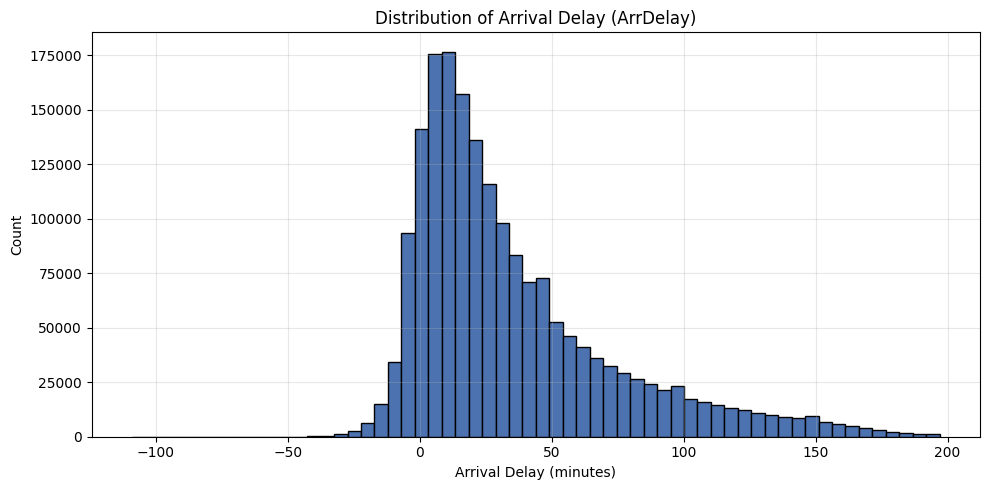

Mean ArrDelay: 35.4356302055068
Median ArrDelay: 23.0
Standard deviation: 38.692482072866135
Skewness: 1.420221398764318
Large delays (> 60 minutes): 0.2029806460314249


In [15]:
plt.figure(figsize=(10, 5))
plt.hist(df['ArrDelay'].dropna(), bins=60, color='#4C72B0', edgecolor='black')
plt.title('Distribution of Arrival Delay (ArrDelay)')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plot_file = image_path / 'arrdelay_distribution.png'
plt.tight_layout()
plt.savefig(plot_file, dpi=200)
plt.show()

print('Mean ArrDelay:', df['ArrDelay'].mean())
print('Median ArrDelay:', df['ArrDelay'].median())
print('Standard deviation:', df['ArrDelay'].std())
print('Skewness:', df['ArrDelay'].skew())
print('Large delays (> 60 minutes):', (df['ArrDelay'] > 60).mean())

### Interpretation

- Histogram giúp ta thấy `ArrDelay` có phân phối lệch phải với một số outlier lớn.  
- Điều này cho thấy Linear Regression có thể bị ảnh hưởng bởi các giá trị delay lớn.  
- Với dữ liệu như này, các mô hình khác hoặc kỹ thuật xử lý outlier có thể cải thiện kết quả.

Data used after dropna: (1868454, 11)

Top features correlated with ArrDelay:
DepDelay          0.909954
DepHour           0.161443
IsRushHour       -0.098766
Dest_Freq         0.062975
Distance         -0.055754
CRSElapsedTime   -0.041968
Origin_Freq       0.010864
IsWeekend        -0.010263


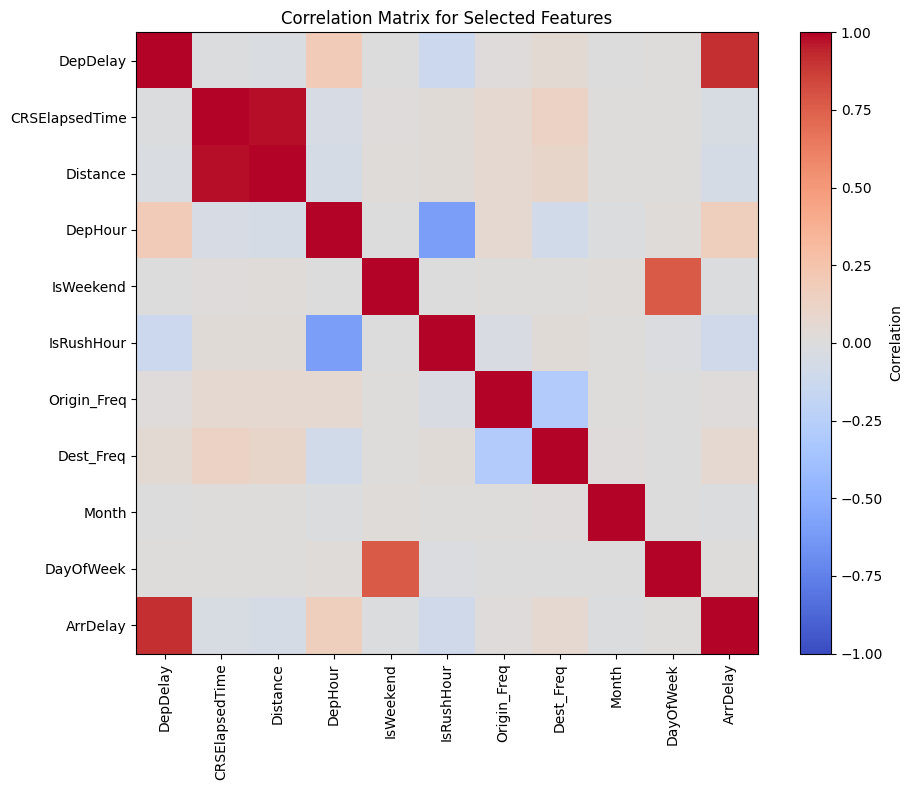

In [16]:
selected_features = [
    'DepDelay',
    'CRSElapsedTime',
    'Distance',
    'DepHour',
    'IsWeekend',
    'IsRushHour',
    'Origin_Freq',
    'Dest_Freq',
    'Month',
    'DayOfWeek'
]
target_column = 'ArrDelay'

analysis_df = df[selected_features + [target_column]].dropna()
print('Data used after dropna:', analysis_df.shape)

corr_matrix = analysis_df.corr()
correlation_target = corr_matrix[target_column].drop(target_column).sort_values(key=abs, ascending=False)
print('\nTop features correlated with ArrDelay:')
print(correlation_target.head(8).to_string())

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('Correlation Matrix for Selected Features')
plt.tight_layout()
heatmap_file = image_path / 'correlation_matrix.png'
plt.savefig(heatmap_file, dpi=200)
plt.show()

### Correlation and Multicollinearity

- Một số feature có tương quan mạnh với `ArrDelay`, ví dụ `DepDelay` và `DepHour`.
- Khi feature có nhiều tương quan với nhau, chúng ta đang gặp **multicollinearity**.  
- Multicollinearity không phá hỏng Linear Regression nhưng có thể làm cho hệ số trở nên khó giải thích và làm tăng phương sai của ước lượng.

## Feature Engineering

- Chọn các feature quan trọng.
- Loại bỏ giá trị thiếu để đảm bảo huấn luyện ổn định.
- Giữ workflow đơn giản, dễ đọc và dễ mở rộng.

In [17]:
feature_df = analysis_df.copy()
feature_df.head()

,DepDelay,CRSElapsedTime,Distance,DepHour,IsWeekend,IsRushHour,Origin_Freq,Dest_Freq,Month,DayOfWeek,ArrDelay
0,8.0,150.0,810,20,0,0,0.011126,0.011779,1,4,-14.0
1,19.0,145.0,810,7,0,1,0.011126,0.011779,1,4,2.0
2,8.0,90.0,515,6,0,1,0.004970,0.015411,1,4,14.0
3,34.0,90.0,515,18,0,0,0.004970,0.015411,1,4,34.0
4,25.0,115.0,688,19,0,0,0.004970,0.004983,1,4,11.0


## Train/Test Split

- Chia dữ liệu thành train/test.
- Đặt `random_state=42` để có thể tái tạo kết quả.

In [18]:
X = feature_df[selected_features]
y = feature_df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print('Training samples:', X_train.shape[0])
print('Test samples:', X_test.shape[0])

Training samples: 1401340
Test samples: 467114


## Feature Scaling

- Linear Regression không bắt buộc phải scaling, nhưng scaling giúp các hệ số dễ so sánh hơn khi feature ở các thang đo khác nhau.
- Ở đây ta dùng `StandardScaler` để chuẩn hóa các feature số.

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaled train shape:', X_train_scaled.shape)
print('Scaled test shape:', X_test_scaled.shape)

Scaled train shape: (1401340, 10)
Scaled test shape: (467114, 10)


## Model Training

- Huấn luyện `LinearRegression` trên dữ liệu đã scaling.
- Đây vẫn là một baseline đơn giản và dễ giải thích.

In [20]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print('Model trained successfully.')

Model trained successfully.


In [ ]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    metrics = {
        'model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse,
        'R2': r2_score(y_true, y_pred)
    }

    print(f"\n{name} evaluation:")
    print(f"MAE:  {metrics['MAE']:.3f}")
    print(f"RMSE: {metrics['RMSE']:.3f}")
    print(f"R2:   {metrics['R2']:.3f}")

    return metrics


def plot_predictions(y_true, y_pred, filename, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.4, s=12)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2)
    plt.xlabel('Actual ArrDelay (minutes)')
    plt.ylabel('Predicted ArrDelay (minutes)')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plot_file = image_path / filename
    plt.savefig(plot_file, dpi=200)
    plt.show()
    print('Saved plot to', plot_file)


def plot_residuals(y_true, y_pred, scatter_file, hist_file):
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals, alpha=0.4, s=12)
    plt.axhline(0, color='red', linewidth=2)
    plt.xlabel('Predicted ArrDelay (minutes)')
    plt.ylabel('Residuals (Actual - Predicted)')
    plt.title('Residuals vs Predicted Values')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    scatter_path = image_path / scatter_file
    plt.savefig(scatter_path, dpi=200)
    plt.show()
    print('Saved residual scatter to', scatter_path)

    plt.figure(figsize=(10, 5))
    plt.hist(residuals, bins=50, color='#55A868', edgecolor='black')
    plt.title('Residual Distribution')
    plt.xlabel('Residual (Actual - Predicted)')
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    hist_path = image_path / hist_file
    plt.savefig(hist_path, dpi=200)
    plt.show()
    print('Saved residual histogram to', hist_path)

    return residuals


def save_metrics(metrics_list, filename):
    metrics_df = pd.DataFrame(metrics_list)
    metrics_path = model_path / filename
    metrics_df.to_csv(metrics_path, index=False)
    print('Saved metrics to', metrics_path)
    return metrics_df

## Evaluation

- MAE: sai số trung bình tuyệt đối.
- RMSE: sai số root mean squared, nhạy với outlier.
- R²: tỷ lệ phương sai được giải thích bởi mô hình.

In [24]:
y_pred = model.predict(X_test_scaled)

lr_metrics = evaluate_model('Linear Regression', y_test, y_pred)

baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_metrics = evaluate_model('Baseline mean predictor', y_test, baseline_pred)

metrics_df = save_metrics([lr_metrics, baseline_metrics], 'linear_regression_metrics.csv')
metrics_df


Linear Regression evaluation:
MAE:  10.804
RMSE: 15.942
R2:   0.830

Baseline mean predictor evaluation:
MAE:  29.564
RMSE: 38.688
R2:   -0.000
Saved metrics to ..\models\linear_regression_metrics.csv


,model,MAE,RMSE,R2
0,Linear Regression,10.804477,15.941813,0.830208
1,Baseline mean predictor,29.564379,38.688282,-0.000005


### Baseline Comparison

- Baseline dự đoán trung bình `ArrDelay` từ tập huấn luyện.  
- Nếu Linear Regression có RMSE thấp hơn baseline, mô hình đang học được một số biến thiên quan trọng.  
- Nếu không, có nghĩa là feature hiện tại chưa đủ mạnh hoặc mô hình quá đơn giản.

Baseline RMSE: 38.688282123652826
Linear Regression RMSE: 15.941812794916144


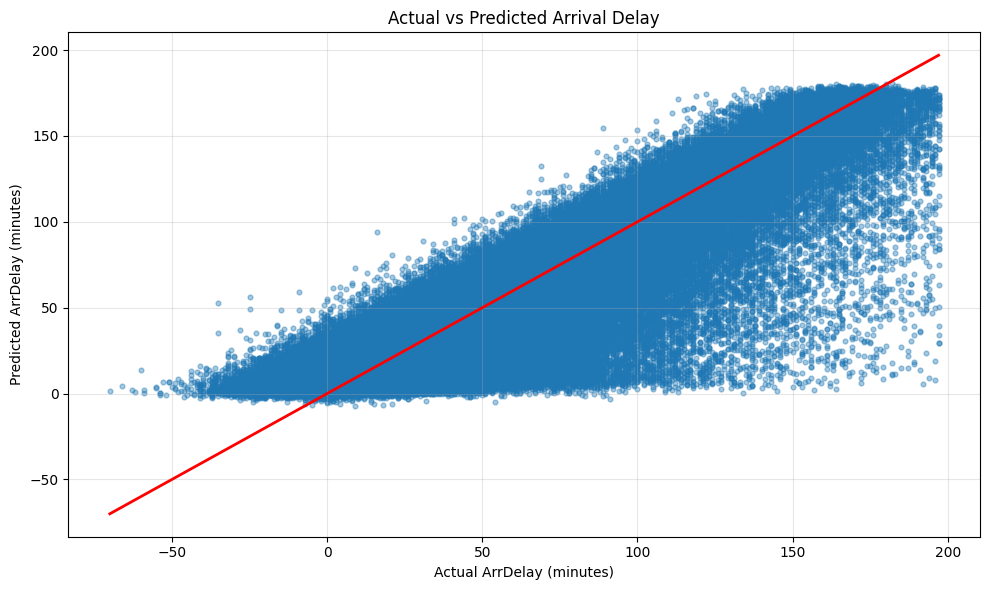

Saved plot to ..\images\actual_vs_predicted.png


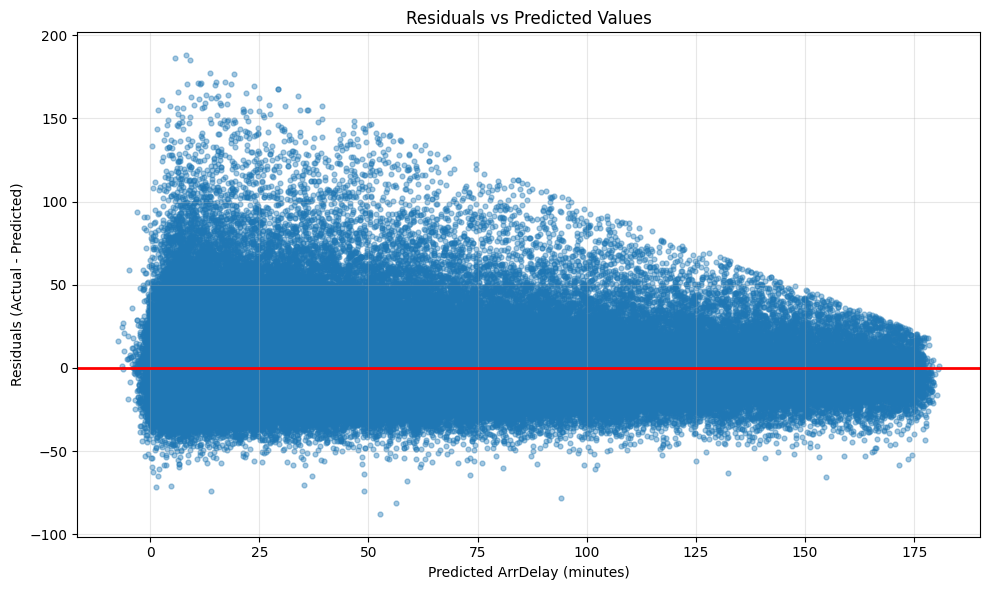

Saved residual scatter to ..\images\residuals_scatter.png


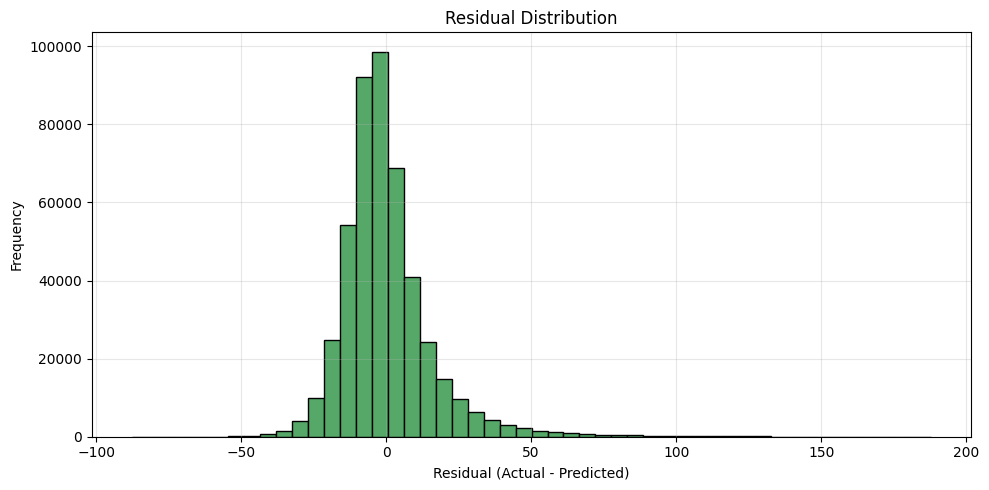

Saved residual histogram to ..\images\residuals_histogram.png


In [25]:
print('Baseline RMSE:', baseline_metrics['RMSE'])
print('Linear Regression RMSE:', lr_metrics['RMSE'])

plot_predictions(y_test, y_pred, 'actual_vs_predicted.png', 'Actual vs Predicted Arrival Delay')
residuals = plot_residuals(y_test, y_pred, 'residuals_scatter.png', 'residuals_histogram.png')

## Residual Analysis

- Residual scatter cho thấy liệu có pattern nào chưa được mô hình bắt được hay không.  
- Nếu residual phân tán ngẫu nhiên quanh 0, thì mô hình tuyến tính phù hợp tương đối tốt.  
- Nếu residual có cấu trúc (vd. hình chữ U hoặc nghiêng), có thể cần feature phi tuyến hoặc mô hình phức tạp hơn.

In [26]:
print('Residual mean:', np.mean(residuals))
print('Residual std:', np.std(residuals))
print('Residual skewness:', pd.Series(residuals).skew())

Residual mean: -0.0529723938432703
Residual std: 15.941724784779174
Residual skewness: 2.113780478551921


## Model Interpretation

- Xây dựng dataframe hệ số để hiểu feature nào ảnh hưởng nhiều nhất.  
- Sắp xếp theo độ lớn tuyệt đối của hệ số để xác định feature quan trọng nhất trong mô hình tuyến tính.

In [27]:
coef_df = pd.DataFrame({
    'feature': selected_features,
    'coefficient': model.coef_
})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coefficient', ascending=False).reset_index(drop=True)
coef_df

,feature,coefficient,abs_coefficient
0,DepDelay,35.239344,35.239344
1,CRSElapsedTime,-1.784142,1.784142
2,Dest_Freq,1.059523,1.059523
3,IsWeekend,-0.669168,0.669168
4,Origin_Freq,0.483365,0.483365
5,DayOfWeek,0.421964,0.421964
6,IsRushHour,0.381734,0.381734
7,Distance,0.360070,0.360070
8,Month,-0.306808,0.306808
9,DepHour,-0.268461,0.268461


- `DepDelay` thường có hệ số lớn nhất, vì delay khi cất cánh là chỉ số mạnh nhất cho độ trễ khi đến.
- Các yếu tố như `CRSElapsedTime` và `Distance` cũng phản ánh hành trình bay và ảnh hưởng tới delay.
- Các biến nhị phân như `IsRushHour` và `IsWeekend` cho biết điều kiện thời gian có thể khiến delay thay đổi.

## Saving Artifacts

- Lưu model và scaler để tái sử dụng.
- Lưu metrics để đối chiếu nhanh khi phát triển thêm.

In [28]:
model_file = model_path / 'linear_regression_arrdelay.pkl'
scaler_file = model_path / 'linear_regression_scaler.pkl'
with open(model_file, 'wb') as f:
    pickle.dump({'model': model, 'features': selected_features}, f)
with open(scaler_file, 'wb') as f:
    pickle.dump(scaler, f)

print('Saved model to', model_file)
print('Saved scaler to', scaler_file)

Saved model to ..\models\linear_regression_arrdelay.pkl
Saved scaler to ..\models\linear_regression_scaler.pkl


## Next Steps

1. Ridge Regression: giảm overfitting và xử lý multicollinearity.
2. Lasso Regression: chọn feature và làm mô hình đơn giản hơn.  
3. Random Forest: bắt được quan hệ phi tuyến và tương tác giữa feature.

**Lý do:** Linear Regression là baseline tốt, nhưng dữ liệu flight delay thường chứa mối quan hệ phi tuyến và biến động phức tạp mà mô hình tuyến tính đơn giản không đủ.